# 01 — Dataset exploration

Before modeling anything, this notebook answers four questions about the raw corpus:

1. **What is actually on disk?** Folder names are treated as claims, not facts — we verify
   them and confirm the `technologie` → `technology` alias.
2. **Is the text usable?** Empty files, unreadable encodings, and extreme length outliers.
3. **Are there duplicates?** Exact duplicates within and across classes, which would leak
   across train/validation/test splits if not removed first.
4. **What does the class balance and text length distribution look like?**

Artifacts saved: `reports/dataset_summary.csv`, `reports/text_length_summary.csv`.

## Setup

In [1]:
import os
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Resolve the repo root whether the notebook runs from notebooks/ or the root.
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config import EXCLUDED_TRAINING_LABELS, LABEL_ALIASES, TRAINED_LABELS
from src.data_loader import load_dataset, text_fingerprint

DATA_DIR = Path(os.environ.get("DATA_DIR", ROOT.parent / "trellis_assessment_ds"))
REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
print("Data dir:", DATA_DIR)

Matplotlib is building the font cache; this may take a moment.


Data dir: /Users/jairfranca/Workspace/job_testing/document_classification_ai/trellis_assessment_ds


## 1. Raw inventory — folder names are claims, not facts

We list every folder and the canonical label it maps to. The dataset ships with a
`technologie` folder (a typo), which the alias map normalizes to `technology`. The
`other` folder is **excluded from training entirely**: it is a 6-document
out-of-distribution (OOD) holdout used only after training to test fallback routing.

In [2]:
folders = sorted(p for p in DATA_DIR.iterdir() if p.is_dir())
inventory = pd.DataFrame(
    {
        "folder": [f.name for f in folders],
        "canonical_label": [LABEL_ALIASES.get(f.name, f.name) for f in folders],
        "raw_files": [len(list(f.glob("*.txt"))) for f in folders],
    }
)
inventory["aliased"] = inventory["folder"] != inventory["canonical_label"]
inventory["role"] = inventory["canonical_label"].map(
    lambda c: "OOD holdout" if c in EXCLUDED_TRAINING_LABELS else "training pool"
)
inventory

,folder,canonical_label,raw_files,aliased,role
0,business,business,100,False,training pool
1,entertainment,entertainment,100,False,training pool
2,food,food,100,False,training pool
3,graphics,graphics,100,False,training pool
4,historical,historical,100,False,training pool
5,medical,medical,100,False,training pool
6,other,other,6,False,OOD holdout
7,politics,politics,100,False,training pool
8,space,space,100,False,training pool
9,sport,sport,100,False,training pool


In [3]:
assert sorted(
    inventory.loc[inventory.role == "training pool", "canonical_label"]
) == TRAINED_LABELS, "Folder labels do not match the expected trained labels"
print("Alias confirmed:", dict(LABEL_ALIASES))
print("10 trained classes x ~100 files, plus a 6-file OOD holdout.")

Alias confirmed: {'technologie': 'technology'}
10 trained classes x ~100 files, plus a 6-file OOD holdout.


## 2. Readability and basic text statistics

Every file is read as UTF-8 with `errors="ignore"` (the same policy the loader uses).
We also attempt a *strict* decode to count files that contain invalid UTF-8 bytes, and
flag empty or near-empty files.

In [4]:
records = []
for folder in folders:
    label = LABEL_ALIASES.get(folder.name, folder.name)
    for path in sorted(folder.glob("*.txt")):
        raw = path.read_bytes()
        try:
            raw.decode("utf-8")
            strict_ok = True
        except UnicodeDecodeError:
            strict_ok = False
        text = raw.decode("utf-8", errors="ignore")
        records.append(
            {
                "label": label,
                "folder": folder.name,
                "path": str(path.relative_to(DATA_DIR)),
                "chars": len(text),
                "words": len(text.split()),
                "strict_utf8": strict_ok,
                "empty": not text.strip(),
                "is_holdout": label in EXCLUDED_TRAINING_LABELS,
            }
        )
raw_df = pd.DataFrame(records)
n_empty = int(raw_df["empty"].sum())
n_bad_utf8 = int((~raw_df.strict_utf8).sum())
print(f"{len(raw_df)} files total | empty: {n_empty} | strict-UTF-8 failures: {n_bad_utf8}")
raw_df.head()

1006 files total | empty: 0 | strict-UTF-8 failures: 0


,label,folder,path,chars,words,strict_utf8,empty,is_holdout
0,business,business,business/business_1.txt,848,149,True,False,False
1,business,business,business/business_10.txt,1585,252,True,False,False
2,business,business,business/business_100.txt,1051,165,True,False,False
3,business,business,business/business_11.txt,3494,595,True,False,False
4,business,business,business/business_12.txt,1667,287,True,False,False


In [5]:
short = raw_df[(~raw_df.is_holdout) & (raw_df.words < 30)].sort_values("words")
long_ = raw_df[~raw_df.is_holdout].nlargest(5, "words")
print(f"Documents under 30 words: {len(short)}")
display(short[["path", "label", "words"]].head(10))
print("Longest documents:")
display(long_[["path", "label", "words"]])

Documents under 30 words: 4


,path,label,words
751,space/space_5.txt,space,19
369,graphics/graphics_71.txt,graphics,21
396,graphics/graphics_96.txt,graphics,24
318,graphics/graphics_25.txt,graphics,29


Longest documents:


,path,label,words
372,graphics/graphics_74.txt,graphics,8052
588,medical/medical_644.txt,medical,4629
560,medical/medical_487.txt,medical,4483
589,medical/medical_645.txt,medical,4227
559,medical/medical_485.txt,medical,4169


## 3. Duplicates — within and across classes

Exact duplicates are detected by hashing case- and whitespace-normalized text
(the same fingerprint the loader uses). If duplicates were left in, the same
document could land in both train and test and inflate every metric. The check
distinguishes duplicates *within* a class from duplicates *across* classes —
the latter would also mean contradictory labels.

In [6]:
known = raw_df[~raw_df.is_holdout & ~raw_df["empty"]].copy()
texts = {
    r.path: (DATA_DIR / r.path).read_text(encoding="utf-8", errors="ignore")
    for r in known.itertuples()
}
known["fingerprint"] = known["path"].map(lambda p: text_fingerprint(texts[p]))

groups = known.groupby("fingerprint").agg(n=("path", "size"), labels=("label", "nunique"))
dup_groups = groups[groups.n > 1]
within = dup_groups[dup_groups.labels == 1]
across = dup_groups[dup_groups.labels > 1]
print(f"Duplicate groups: {len(dup_groups)} "
      f"(within-class: {len(within)}, cross-class: {len(across)})")
print(f"Redundant copies to drop: {int((dup_groups.n - 1).sum())}")

dup_detail = known[known.fingerprint.isin(dup_groups.index)].sort_values("fingerprint")
dup_detail[["fingerprint", "label", "path", "words"]].assign(
    fingerprint=lambda d: d.fingerprint.str[:10]
)

Duplicate groups: 8 (within-class: 8, cross-class: 0)
Redundant copies to drop: 8


,fingerprint,label,path,words
854,0b64846902,sport,sport/sport_52.txt,142
889,0b64846902,sport,sport/sport_84.txt,142
142,2a33ada96d,entertainment,entertainment/entertainment_47.txt,192
155,2a33ada96d,entertainment,entertainment/entertainment_59.txt,192
929,4ef3e835e2,technology,technologie/technologie_3.txt,212
936,4ef3e835e2,technology,technologie/technologie_36.txt,212
49,73dcca037f,business,business/business_53.txt,375
81,73dcca037f,business,business/business_82.txt,375
656,7cd7d8d989,politics,politics/politics_217.txt,274
698,7cd7d8d989,politics,politics/politics_321.txt,274


The loader applies exactly this dedup before any split. Cross-checking the loader's
own report against the manual count above:

In [7]:
ds = load_dataset(DATA_DIR)
print("Loader duplicate report:", ds.duplicate_report)
print("Loader empty-file report:", ds.empty_files or "none")
print(f"Known pool after dedup: {len(ds.known_texts)} docs | OOD holdout: {len(ds.other_texts)} docs")
assert ds.duplicate_report["total_removed"] == int((dup_groups.n - 1).sum())

Loader duplicate report: {'total_removed': 8, 'cross_class_removed': 0, 'business': 1, 'entertainment': 2, 'politics': 2, 'sport': 2, 'technology': 1}
Loader empty-file report: none
Known pool after dedup: 992 docs | OOD holdout: 6 docs


## 4. Class balance and text length distributions

Class counts after dedup, then word-count distributions per class. Two distinct
registers are visible in this corpus: edited news articles (e.g. `business`, `sport`)
and raw newsgroup posts with headers and quoting (e.g. `graphics`, `space`, `medical`).

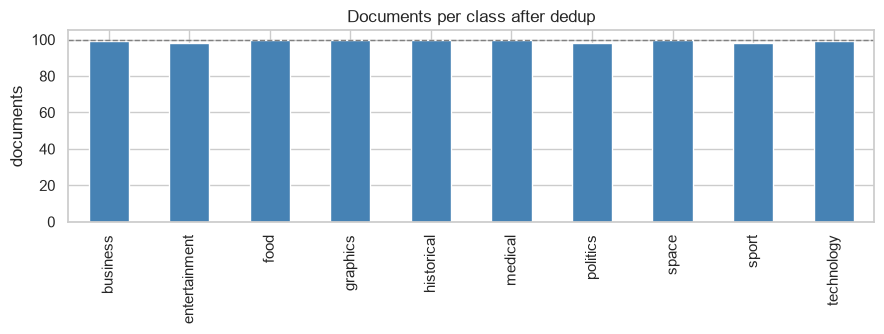

,business,entertainment,food,graphics,historical,medical,politics,space,sport,technology
docs_after_dedup,99,98,100,100,100,100,98,100,98,99


In [8]:
counts = pd.Series(Counter(ds.known_labels)).sort_index()
fig, ax = plt.subplots(figsize=(9, 3.5))
counts.plot.bar(ax=ax, color="steelblue")
ax.set_title("Documents per class after dedup")
ax.set_ylabel("documents")
ax.axhline(100, color="grey", ls="--", lw=1)
plt.tight_layout()
plt.show()
counts.to_frame("docs_after_dedup").T

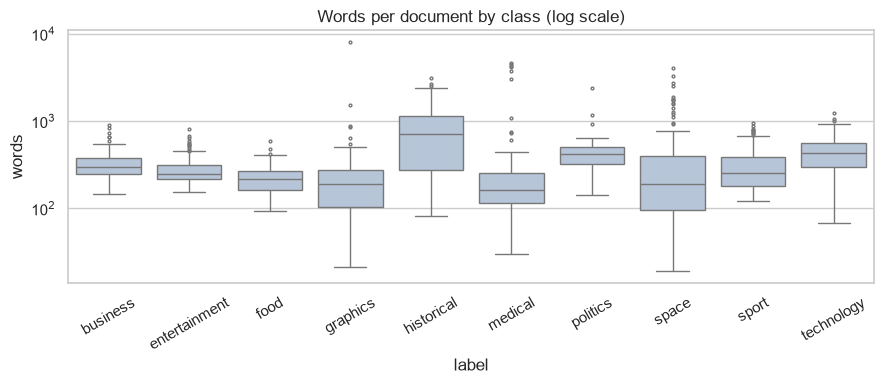

In [9]:
known_dedup = known[~known.fingerprint.duplicated(keep="first")]
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=known_dedup, x="label", y="words", ax=ax, color="lightsteelblue",
            fliersize=2, order=TRAINED_LABELS)
ax.set_yscale("log")
ax.set_title("Words per document by class (log scale)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [10]:
# Two registers: an edited news article vs. a raw newsgroup post.
def preview(label):
    row = known_dedup[known_dedup.label == label].iloc[0]
    print(f"--- {row.path} ({row.words} words) ---")
    print(texts[row.path][:400].strip(), "...\n")

preview("business")
preview("space")

--- business/business_1.txt (149 words) ---
Lufthansa flies back to profit

German airline Lufthansa has returned to profit in 2004 after posting huge losses in 2003.

In a preliminary report, the airline announced net profits of 400m euros ($527.61m; £274.73m), compared with a loss of 984m euros in 2003. Operating profits were at 380m euros, ten times more than in 2003. Lufthansa was hit in 2003 by tough competition and a dip in demand fol ...

--- space/space_1.txt (231 words) ---
In article <C4KvJF.4qo@well.sf.ca.us> metares@well.sf.ca.us (Tom Van Flandern) writes:
>crb7q@kelvin.seas.Virginia.EDU (Cameron Randale Bass) writes:
>> Bruce.Scott@launchpad.unc.edu (Bruce Scott) writes:
>>> "Existence" is undefined unless it is synonymous with "observable" in
>>> physics.
>> [crb] Dong ....  Dong ....  Dong ....  Do I hear the death-knell of
>> string theory?
>     I agree.  You ...



## 5. Save report artifacts

In [11]:
length_stats = (
    known_dedup.groupby("label")["words"].describe().round(1).rename_axis("label")
)
length_stats.to_csv(REPORTS_DIR / "text_length_summary.csv")

dups_removed = known.groupby("label")["fingerprint"].apply(
    lambda s: int(s.duplicated().sum())
)
summary = pd.DataFrame(
    {
        "raw_files": raw_df[~raw_df.is_holdout].groupby("label").size(),
        "empty_files": raw_df[~raw_df.is_holdout].groupby("label")["empty"].sum().astype(int),
        "duplicates_removed": dups_removed,
        "docs_after_dedup": counts,
        "median_words": known_dedup.groupby("label")["words"].median().astype(int),
    }
).rename_axis("label")
summary.loc["TOTAL"] = summary.sum(numeric_only=True)
summary.loc["TOTAL", "median_words"] = int(known_dedup["words"].median())
summary = summary.astype(int)
summary.to_csv(REPORTS_DIR / "dataset_summary.csv")
summary

,raw_files,empty_files,duplicates_removed,docs_after_dedup,median_words
label,,,,,
business,100,0,1,99,297
entertainment,100,0,2,98,244
food,100,0,0,100,217
graphics,100,0,0,100,192
historical,100,0,0,100,704
medical,100,0,0,100,163
politics,100,0,2,98,420
space,100,0,0,100,190
sport,100,0,2,98,256


In [12]:
display(length_stats)

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
business,99.0,329.8,137.7,147.0,248.0,297.0,375.0,891.0
entertainment,98.0,288.0,123.1,152.0,215.2,244.5,311.5,806.0
food,100.0,226.5,85.2,94.0,163.0,217.5,266.2,594.0
graphics,100.0,310.3,808.1,21.0,103.0,192.0,273.5,8052.0
historical,100.0,842.5,674.0,82.0,271.8,704.0,1156.0,3082.0
medical,100.0,435.6,940.7,30.0,115.0,163.5,256.0,4629.0
politics,98.0,438.3,254.5,142.0,320.2,420.0,508.5,2393.0
space,100.0,465.4,713.2,19.0,94.8,190.5,396.5,4033.0
sport,98.0,319.3,195.2,122.0,181.0,256.0,384.5,944.0


## Takeaways

- **Balanced corpus**: ~100 docs per class, 992 usable documents after removing 8 exact
  duplicate copies. No empty or unreadable files.
- **Alias handled**: `technologie` folder confirmed as a typo and normalized to
  `technology` in code, not by renaming data on disk.
- **Duplicates were all within-class** — no contradictory labels — but they still had to
  be removed *before* splitting to avoid train/test leakage.
- **Mixed provenance**: edited news articles vs. raw newsgroup posts (headers, quoting,
  signatures). Newsgroup noise tokens are something TF-IDF with `min_df`/`max_df`
  pruning handles reasonably; worth remembering when reading errors later.
- **Length varies by an order of magnitude** across and within classes, which supports
  sublinear TF scaling in the vectorizer.
- **The 6 `other` docs stay untouched** until final OOD evaluation.